# Final Project: Multi-temporal Sentinel-2 Land Cover Segmentation and Elephant Habitat Suitability in Thailand's EFCOM Region

**Course:** MUSA 650  
**Group Members:** Jinyang Xu, Qianmu Zheng, Xiao Yu  
**Submission Date:** April 23, 2026

This notebook documents our final project workflow for land cover segmentation and downstream elephant habitat suitability modeling in Thailand's EFCOM region. Part I develops a five-class semantic segmentation pipeline using multi-temporal Sentinel-2 imagery and JAXA-derived reference labels. Part II uses the resulting land cover composition features, together with NDVI and occurrence points, to build a habitat suitability model and generate a spatial probability surface.


## Assignment Instructions

This notebook is organized to satisfy the course final project requirements described in the official assignment brief: [FINAL_PROJECT.md](https://github.com/MUSA-650/musa-650-spring2026/blob/main/assignments/FINAL_PROJECT.md).

The final project requires a machine-learning-based remote sensing solution that:

- defines a clear planning problem, target user, and output product;
- justifies the technical approach and revisits anticipated failure modes;
- summarizes methodological precedent from at least three sources;
- documents data sources, spatial and temporal extent, preprocessing, and feature engineering;
- presents a non-deep-learning baseline before the primary model;
- reports evaluation metrics with both quantitative and visual analysis;
- discusses limitations honestly and proposes future work;
- supports a professional five-minute lightning talk.

Submission expectations also require a readable notebook with well-formatted code chunks, group member names, submission date, and any supporting files placed in a companion folder. In this working draft, we emphasize reproducible structure, figures, tables, and code references; group members can refine the prose and literature discussion before final submission.

## Project Overview

Our project has two connected parts:

1. **Land cover segmentation:** build a five-class segmentation model from Sentinel-2 imagery and JAXA-derived labels.
2. **Habitat suitability modeling:** convert segmentation outputs into landscape composition features and combine them with NDVI and elephant occurrence data.

The segmentation model is the foundation of the full workflow because it converts raw satellite imagery into ecologically meaningful land-cover categories.

```mermaid
flowchart LR
    A["Sentinel-2 bi-monthly composites"] --> B["5-class land cover segmentation"]
    C["JAXA 10 m reference labels"] --> B
    B --> D["Land-cover composition features"]
    E["NDVI and occurrence data"] --> F["Habitat suitability modeling"]
    D --> F
    F --> G["Elephant habitat suitability map"]
```

## Problem Definition & Technical Justification

Asian elephants increasingly occupy fragmented landscapes rather than large, continuous forest blocks. For conservation planning, this means that understanding habitat suitability requires more than a single vegetation indicator: it requires a spatially explicit description of surrounding land cover, including forest, plantation, cropland, human-used areas, and wetlands.

Our target users are conservation planners, regional land managers, and researchers studying elephant movement and habitat use in Thailand's EFCOM region. The main output of Part I is a five-class land cover segmentation map. The main output of Part II is a habitat suitability surface derived from land cover composition and vegetation features.

Technically, our segmentation model learns the relationship between a **24-channel multi-temporal Sentinel-2 feature stack** and a **5-class land cover label raster**. We first establish a performance floor using a traditional pixel-based Random Forest baseline, then introduce a U-Net model that can incorporate spatial context and parcel structure.

**Anticipated failure modes**

- confusion between plantation and forest;
- noise inherited from remapped JAXA labels;
- imperfect generalization outside the training region;
- optimistic validation due to overlapping patches;
- constrained model tuning because training was performed on local hardware.

We return to these failure modes in the evaluation and limitations sections.

## Methodological Precedent

The implementation draws on four sources that informed category design, data choices, and modeling strategy.

### Source 1: Ecological Justification for Landscape Categories
**Citation:** He et al. (2023). Evaluation of Habitat Suitability for Asian Elephants in Sipsongpanna under Climate Change by Coupling Multi-Source Remote Sensing Products with MaxEnt Model.

This study demonstrates that elephant activity is closely associated with forest condition, water access, human disturbance, and agricultural expansion. Although it uses MaxEnt rather than segmentation, it provides ecological justification for why our five target classes — forest, plantation, cropland, human-use, and water/wetland — are the right analytical vocabulary for describing elephant activity landscapes. We borrow the ecological logic behind category selection rather than the MaxEnt model itself.

### Source 2: Separating Plantation and Agricultural Classes in Sentinel-2
**Citation:** Nomura et al. (2018). More Than Meets the Eye: Using Sentinel-2 to Map Small-Scale Plantations in Complex Forest Landscapes.

This source directly addresses whether plantation and agricultural subtypes can be distinguished in Sentinel-2 imagery in complex Southeast Asian landscapes. Using Random Forest classification with spectral bands, vegetation indices, and texture features, the study achieved over 95% accuracy while separating oil palm, rubber, and other plantation classes. It supports our decision to treat Plantation as a distinct target class and motivates the use of multi-temporal composites — rather than single-date imagery — to improve spectral separability between forest, plantation, and cropland.

### Source 3: Semantic Segmentation for Fragmented Habitat Mapping
**Citation:** van der Plas et al. (2023). Multi-Stage Semantic Segmentation Quantifies Fragmentation of Small Habitats at a Landscape Scale.

This paper proposes a staged semantic segmentation framework using a U-Net-style pipeline, showing that predicting broad classes first and then refining subclasses within those masks improves performance on difficult fine-grained categories. High-level classes reached ~95% accuracy, while finer classes ranged between 72–92%. This work informed our understanding of where flat one-shot segmentation is likely to struggle — particularly for Plantation, which shares spectral similarity with Forest — and supports the iterative model design we adopted (U-Net v1 → U-Net v2).

### Source 4: Occurrence-Based Landscape Analysis for Elephants in EFCOM
**Citation:** Suksavate et al. (2023). Quantifying Landscape Connectivity and Potential Corridors for Wild Asian Elephants in Eastern Thailand. *Diversity*, 15, 6.

This study uses elephant occurrence data combined with environmental variables — land use, forest type, elevation, distance to roads, water, and settlements — to model landscape resistance and connectivity in the same EFCOM region we study. It directly justifies using occurrence points to relate elephant presence to landscape conditions. We adapt this approach by applying it within a Random Forest model that uses segmented land-cover composition (from Part I) to generate a continuous habitat suitability probability surface rather than modeling connectivity.


## Study Area and Data Sources

We distinguish between two spatial extents:

- **Study region:** the final application area where we generate the land cover map.
- **Outer region:** the surrounding area used to generate training patches while excluding the final study region from the training manifest.

This setup reduces leakage between training and final prediction and creates a more realistic transfer task: the model learns from nearby landscapes and is then applied to the target area.

**Area summary**

| Region | Approximate area |
|---|---:|
| Study region | 18,227 square miles |
| Outer region | 39,606 square miles |

![Study region and outer region](final_project_files/figures/template_scope_map.png)

**Main datasets**

| Dataset | Source | Resolution | Time period | Role |
|---|---|---:|---|---|
| Sentinel-2 Surface Reflectance | Google Earth Engine | 10 m | 2023 | imagery input |
| JAXA Southeast Asia land cover | JAXA | 10 m | 2023 product | reference labels |
| Boundary geometry | project boundary file | n/a | current project extent | clipping and AOI definition |

In [4]:
# Helper imports used in the lightweight, reproducible parts of this notebook.
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

ROOT = Path(".")
FILES = ROOT / "final_project_files"
FIG_DIR = FILES / "figures"
TABLE_DIR = FILES / "tables"

In [5]:
# Quick sanity check that the notebook can see the packaged project files.
sorted([p.name for p in FIG_DIR.iterdir()])[:20]

['alignment_example.png',
 'best_patch_all_models.png',
 'class_legend.png',
 'no_city_patch_all_models.png',
 'patch_extraction_example.png',
 'studyregion_label_map.png',
 'studyregion_rf_map.png',
 'studyregion_unet_map.png',
 'template_scope_map.png',
 'template_sentinel_stack.png',
 'training_curves_v1_v2.png',
 'validation_confusion_matrix_three_models.png',
 'validation_overall_metrics_for_template.png',
 'validation_per_class_f1_for_template.png']

---

# Part 1: Landscape Segmentation

## Data & Preprocessing

The preprocessing pipeline has four main steps:

1. Export multi-temporal Sentinel-2 composites from Google Earth Engine.
2. Remap the original JAXA classes into a five-class scheme.
3. Align labels to the exact imagery grid.
4. Generate overlapping 512 x 512 patches for model training and validation.

The code below records these steps explicitly, even when the heavy computation is not rerun inside the notebook.

### Step 1. Sentinel-2 export from Google Earth Engine

We exported six bi-monthly composites for 2023 and kept four 10 m bands per period: Blue, Green, Red, and NIR. This produced a **24-channel stack** per pixel.

**Key implementation idea**
- filter Sentinel-2 by date and region;
- join with cloud probability;
- apply cloud masking;
- take the median composite for each bi-monthly period;
- stack the six composites into one 24-band image.

```javascript
// final_project_files/scripts/earth_engine_export_s2_bimonthly_stack.js
var aoi = ee.FeatureCollection('users/your_username/your_aoi_asset');
var region = aoi.geometry();

var s2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED');
var clouds = ee.ImageCollection('COPERNICUS/S2_CLOUD_PROBABILITY');

var periods = [
  {name: 'jan_feb', start: '2023-01-01', end: '2023-03-01'},
  {name: 'mar_apr', start: '2023-03-01', end: '2023-05-01'},
  {name: 'may_jun', start: '2023-05-01', end: '2023-07-01'},
  {name: 'jul_aug', start: '2023-07-01', end: '2023-09-01'},
  {name: 'sep_oct', start: '2023-09-01', end: '2023-11-01'},
  {name: 'nov_dec', start: '2023-11-01', end: '2024-01-01'}
];

function maskClouds(img) {
  var cloudProb = ee.Image(
    clouds.filter(ee.Filter.eq('system:index', img.get('system:index'))).first()
  ).select('probability');
  var mask = cloudProb.lt(40);
  return img.updateMask(mask).clip(region);
}

function makePeriodComposite(period) {
  period = ee.Dictionary(period);
  var filtered = s2
    .filterBounds(region)
    .filterDate(period.getString('start'), period.getString('end'))
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 80))
    .map(maskClouds)
    .select(['B2', 'B3', 'B4', 'B8']);

  var composite = filtered.median();
  return composite.rename([
    period.getString('name').cat('_B2'),
    period.getString('name').cat('_B3'),
    period.getString('name').cat('_B4'),
    period.getString('name').cat('_B8')
  ]);
}

var stack = ee.ImageCollection(periods.map(makePeriodComposite)).toBands();
Export.image.toDrive({
  image: stack,
  description: 'thailand_aoi_s2_2023_bimonthly_24ch',
  region: region,
  scale: 10,
  crs: 'EPSG:32647',
  maxPixels: 1e13
});
```

![Sentinel-2 multi-temporal stack](final_project_files/figures/template_sentinel_stack.png)

### Step 2. Class remapping from JAXA to the project-specific 5-class schema

The original JAXA product contains a richer class inventory than we use in the final segmentation target. We remapped the labels into five classes and assigned `Bare` and `Grassland` to the ignore category.

```yaml
# final_project_files/configs/class_mapping_5class.yaml
target_names:
  1: Forest
  2: Plantation
  3: Cropland
  4: Human-use
  5: Water/Wetland

raw_to_target:
  1: 5
  2: 4
  3: 4
  4: 3
  5: 3
  6: 3
  7: 5
  9: 1
  10: 1
  11: 1
  12: 2
  13: 2
  14: 1

ignored_raw_classes:
  - 8
  - 15
```

```python
# final_project_files/scripts/reclass_and_clip_jaxa.py
def remap_labels(labels: np.ndarray, raw_to_target: dict[int, int]) -> np.ndarray:
    output = np.zeros(labels.shape, dtype=np.uint8)
    for raw_class, target_class in raw_to_target.items():
        output[labels == raw_class] = target_class
    return output

def clip_and_reclassify(tif_path, geometries, aoi_crs, raw_to_target, output_path):
    with rasterio.open(tif_path) as src:
        transformed_geometries = geometries
        if aoi_crs and src.crs and str(aoi_crs) != str(src.crs):
            transformed_geometries = [
                transform_geom(aoi_crs, src.crs, geometry) for geometry in geometries
            ]

        clipped, transform = mask(src, transformed_geometries, crop=True)
        labels = clipped[0]
        mapped = remap_labels(labels, raw_to_target)

        profile = src.profile.copy()
        profile.update(count=1, dtype='uint8', nodata=0, compress='lzw')
        with rasterio.open(output_path, 'w', **profile) as dst:
            dst.write(mapped, 1)
```

**Resulting five classes**

| Output class | JAXA classes |
|---|---|
| Forest | DBF, EBF, ENF, Mangrove |
| Plantation | Rubber Tree Plantation, Oil Palm Tree Plantation |
| Cropland | Cropland, Single-crop Paddy, Multi-crop Paddy |
| Human-use | Built-up, Solar Panel |
| Water/Wetland | Water Bodies, Herbaceous Wetland |

### Step 3. Align labels to the imagery grid

Because the model reads imagery and labels together by raster window, the labels must match the imagery **exactly** in CRS, transform, height, and width. We therefore reprojected the remapped labels onto the exact Sentinel-2 grid using nearest-neighbor resampling.

```python
# final_project_files/scripts/align_labels_to_imagery.py
with rasterio.open(args.image) as img_ds, rasterio.open(args.label) as lbl_ds:
    destination = np.full((img_ds.height, img_ds.width), args.label_nodata, dtype=np.uint8)

    reproject(
        source=rasterio.band(lbl_ds, 1),
        destination=destination,
        src_transform=lbl_ds.transform,
        src_crs=lbl_ds.crs,
        src_nodata=lbl_ds.nodata if lbl_ds.nodata is not None else args.label_nodata,
        dst_transform=img_ds.transform,
        dst_crs=img_ds.crs,
        dst_nodata=args.label_nodata,
        resampling=Resampling.nearest,
    )
```

**Visual sanity check**

The figure below shows a crop from an aligned RGB tile and its aligned five-class label. This step is critical because even a small grid mismatch would break patch-based training.

![Alignment example](final_project_files/figures/alignment_example.png)

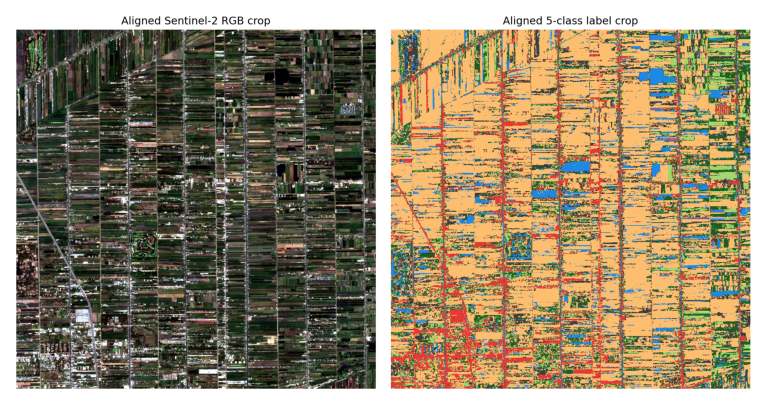

In [6]:
# Display the alignment figure inside the notebook as a quick reproducible check.
fig = mpimg.imread(FIG_DIR / "alignment_example.png")
plt.figure(figsize=(10, 5))
plt.imshow(fig)
plt.axis("off")
plt.show()

### Step 4. Generate overlapping training patches

We exported overlapping `512 x 512` patches with a `256` pixel stride. Overlap increases sample count and reduces edge effects, though it also introduces spatial correlation between neighboring samples.

```python
# final_project_files/scripts/tile_training_data.py
for row in range(0, img_ds.height - args.tile_size + 1, args.stride):
    for col in range(0, img_ds.width - args.tile_size + 1, args.stride):
        window = Window(col, row, args.tile_size, args.tile_size)
        image = img_ds.read(window=window).astype(np.float32)
        label = lbl_ds.read(1, window=window).astype(np.uint8)

        labeled_ratio = float(np.count_nonzero(label)) / float(label.size)
        if labeled_ratio < args.min_labeled_ratio:
            continue

        tile_id = f"{image_path.stem}_r{row}_c{col}"
        manifest_rows.append([
            tile_id,
            str(image_path.resolve()),
            str(label_path.resolve()),
            row,
            col,
            args.tile_size,
        ])
```

We then split the manifest into training and validation sets:

- Train patches: **6,042**
- Validation patches: **1,379**

![Patch extraction example](final_project_files/figures/patch_extraction_example.png)

In [7]:
# Patch split summary used by the training and evaluation pipeline.
split_df = pd.DataFrame(
    {
        "Split": ["Train", "Validation"],
        "Patches": [6042, 1379],
        "Approx. ratio": ["81.4%", "18.6%"],
    }
)
split_df

,Split,Patches,Approx. ratio
0,Train,6042,81.4%
1,Validation,1379,18.6%


## Exploratory Visual Checks

Before training, we visually verified that:

- the study and outer region extents were correct;
- the Sentinel-2 RGB rendering looked spatially coherent;
- the five-class labels aligned with the imagery grid;
- no obvious projection mismatch was present after preprocessing.

The final project figures are included as static images rather than interactive widgets so they render reliably on GitHub.

![Class legend](final_project_files/figures/class_legend.png)

## Modeling Approach

Following the assignment instructions, we present a **baseline model first**, then the primary deep learning model.

### Baseline Implementation: Random Forest

We use a **Random Forest classifier** as the non-deep-learning baseline. This is a strong baseline for remote sensing because it performs well on structured spectral features and is relatively efficient to train.

**Design summary**

| Item | Setting |
|---|---|
| Input | pixel-level 24-channel Sentinel-2 features |
| Output | 5 classes |
| Training pixels | 614,400 |
| Validation pixels | 204,800 |
| Trees | 200 |
| Max depth | 24 |
| Class weighting | `balanced_subsample` |
| Feature normalization | global mean/std |

The baseline uses only per-pixel features and does **not** model spatial context.

```python
# final_project_files/scripts/train_random_forest_baseline.py
def sample_pixels_from_window(row, pixels_per_patch, rng):
    tile_size = int(row["tile_size"])
    win = Window(int(row["col"]), int(row["row"]), tile_size, tile_size)

    with rasterio.open(row["image_path"]) as img_ds:
        image = img_ds.read(window=win).astype(np.float32)
    with rasterio.open(row["label_path"]) as lbl_ds:
        label = lbl_ds.read(1, window=win).astype(np.uint8)

    valid = np.flatnonzero(label.reshape(-1) > 0)
    chosen = rng.choice(valid, size=min(pixels_per_patch, valid.size), replace=False)
    flat_image = image.reshape(image.shape[0], -1).T
    x = flat_image[chosen]
    y = label.reshape(-1)[chosen] - 1
    return x, y

# Global feature normalization for numerical stability
mean = x_train.mean(axis=0, keepdims=True)
std = np.clip(x_train.std(axis=0, keepdims=True), 1e-6, None)
x_train = (x_train - mean) / std
x_val = (x_val - mean) / std

clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=24,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42,
)
clf.fit(x_train, y_train)
pred = clf.predict(x_val)
```

In [8]:
# Load the saved validation metrics for the baseline.
rf = json.loads((TABLE_DIR / "random_forest_validation_metrics.json").read_text())
pd.DataFrame(
    [{"Metric": "Accuracy", "Value": rf["accuracy"]},
     {"Metric": "Macro F1", "Value": rf["macro_f1"]},
     {"Metric": "mIoU", "Value": rf["miou"]}]
)

,Metric,Value
0,Accuracy,0.889028
1,Macro F1,0.762008
2,mIoU,0.631609


### Baseline Results

We evaluate all primary metrics on the **held-out validation patches**, not on the final study-region application map.

**Random Forest validation performance**

| Metric | Value |
|---|---:|
| Accuracy | 88.9% |
| Macro F1 | 76.2% |
| mIoU | 63.2% |

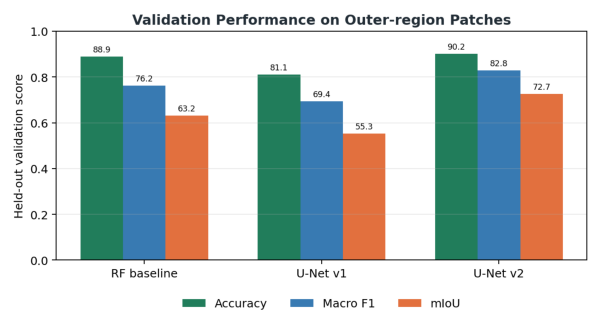

In [9]:
# Show the shared validation metric figure that compares all three models.
fig = mpimg.imread(FIG_DIR / "validation_overall_metrics_for_template.png")
plt.figure(figsize=(8, 4))
plt.imshow(fig)
plt.axis("off")
plt.show()

### Primary Model Implementation: U-Net Semantic Segmentation

Our primary model is **U-Net**, which is better suited to semantic segmentation because it uses spatial context and skip connections to reconstruct parcel-scale masks.

#### U-Net v1

| Item | Setting |
|---|---|
| Architecture | U-Net |
| Encoder | ResNet34 |
| Decoder | standard U-Net decoder |
| Pretrained weights | none |
| Input channels | 24 |
| Output classes | 5 |
| Normalization | patch-wise |
| Loss | Cross Entropy |
| Optimizer | AdamW |
| Learning rate | 1e-3 |
| Batch size | 2 |
| Epochs | 5 |

#### U-Net v2

| Item | Setting |
|---|---|
| Architecture | U-Net |
| Encoder | ResNet18 |
| Decoder | standard U-Net decoder |
| Pretrained weights | none |
| Input channels | 24 |
| Output classes | 5 |
| Normalization | global train-set normalization |
| Loss | weighted Cross Entropy + 0.5 Dice |
| Optimizer | AdamW |
| Learning rate | 1e-3 |
| Batch size | 2 |
| Epochs | 8 |

U-Net v1 had not fully converged and showed unstable behavior, so U-Net v2 extended training by 3 additional epochs and improved normalization and loss design.

```python
# final_project_files/scripts/train_unet.py
class WindowDataset(Dataset):
    def __getitem__(self, index):
        row = self.rows[index]
        win = rasterio.windows.Window(int(row["col"]), int(row["row"]), tile_size, tile_size)
        with rasterio.open(row["image_path"]) as img_ds:
            image = img_ds.read(window=win).astype(np.float32)
        with rasterio.open(row["label_path"]) as lbl_ds:
            label = lbl_ds.read(1, window=win).astype(np.int64)

        if self.normalization == "global":
            mean = self.norm_mean
            std = self.norm_std
        else:
            mean = image.mean(axis=(1, 2), keepdims=True)
            std = image.std(axis=(1, 2), keepdims=True)

        image = (image - mean) / np.clip(std, 1e-6, None)
        label = np.where(label == 0, 255, label - 1).astype(np.int64)
        return torch.from_numpy(image), torch.from_numpy(label)

def build_model(args):
    encoder_weights = "imagenet" if args.in_channels == 3 else None
    return smp.Unet(
        encoder_name=args.encoder,
        encoder_weights=encoder_weights,
        in_channels=args.in_channels,
        classes=args.num_classes,
    )
```

```python
# Weighted cross entropy + Dice loss used in U-Net v2
class SegmentationLoss(nn.Module):
    def __init__(self, num_classes, class_weights=None, dice_weight=0.0):
        super().__init__()
        self.num_classes = num_classes
        self.dice_weight = dice_weight
        self.ce = nn.CrossEntropyLoss(weight=class_weights, ignore_index=255)

    def forward(self, logits, target):
        loss = self.ce(logits, target)
        if self.dice_weight <= 0:
            return loss

        valid = target != 255
        safe_target = target.masked_fill(~valid, 0)
        probs = torch.softmax(logits, dim=1)
        one_hot = F.one_hot(safe_target, num_classes=self.num_classes).permute(0, 3, 1, 2).float()
        valid = valid.unsqueeze(1)
        probs = probs * valid
        one_hot = one_hot * valid

        intersection = (probs * one_hot).sum((0, 2, 3))
        denominator = probs.sum((0, 2, 3)) + one_hot.sum((0, 2, 3))
        dice = (2.0 * intersection + 1e-6) / (denominator + 1e-6)
        return loss + self.dice_weight * (1.0 - dice.mean())
```

```python
# final_project_files/scripts/train_unet.py
model = build_model(args).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr)

for epoch in range(1, args.epochs + 1):
    train_loss, train_iou, _ = run_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        num_classes=args.num_classes,
    )
    val_loss, val_iou, val_per_class_iou = run_epoch(
        model=model,
        loader=val_loader,
        optimizer=None,
        criterion=criterion,
        device=device,
        num_classes=args.num_classes,
    )

    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(), args.output_dir / "best_model.pt")
```

In [10]:
# Load the saved validation metrics for both U-Net runs.
unet_v1 = json.loads((TABLE_DIR / "unet_v1_validation_metrics.json").read_text())
unet_v2 = json.loads((TABLE_DIR / "unet_v2_validation_metrics.json").read_text())

metrics_df = pd.DataFrame(
    [
        {"Model": "Random Forest baseline", "Accuracy": rf["accuracy"], "Macro F1": rf["macro_f1"], "mIoU": rf["miou"]},
        {"Model": "U-Net v1", "Accuracy": unet_v1["accuracy"], "Macro F1": unet_v1["macro_f1"], "mIoU": unet_v1["miou"]},
        {"Model": "U-Net v2", "Accuracy": unet_v2["accuracy"], "Macro F1": unet_v2["macro_f1"], "mIoU": unet_v2["miou"]},
    ]
)
metrics_df

,Model,Accuracy,Macro F1,mIoU
0,Random Forest baseline,0.889028,0.762008,0.631609
1,U-Net v1,0.811323,0.693690,0.552638
2,U-Net v2,0.901947,0.827958,0.726860


### Model Complexity and Runtime Notes

From a model-design perspective, **U-Net v1 is heavier per epoch** because it uses a deeper ResNet34 encoder. **U-Net v2 is lighter per step** because it switches to ResNet18, but it runs for more epochs.

| Item | U-Net v1 | U-Net v2 |
|---|---:|---:|
| Encoder | ResNet34 | ResNet18 |
| Model file size | 93.6 MB | 55.0 MB |
| Epochs | 5 | 8 |
| Steps per epoch | 3,021 | 3,021 |
| Total train steps | 15,105 | 24,168 |

The performance gain in U-Net v2 comes primarily from **better normalization and loss design**, not from a larger encoder.

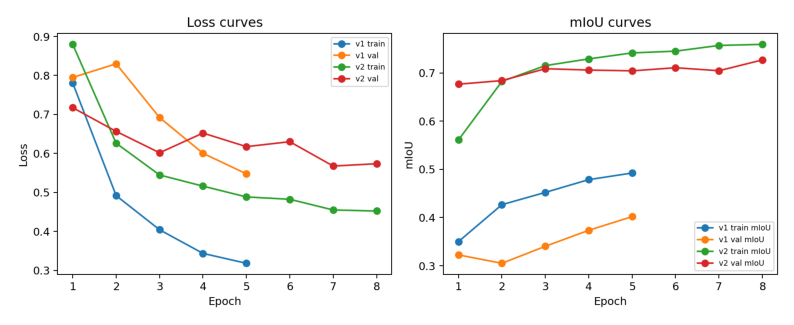

In [11]:
# Show the training curves for the two U-Net runs.
fig = mpimg.imread(FIG_DIR / "training_curves_v1_v2.png")
plt.figure(figsize=(10, 4))
plt.imshow(fig)
plt.axis("off")
plt.show()

### Evaluation code

We evaluated the trained model on the held-out patch split using a separate script that loads the saved weights, runs inference over each validation window, and computes overall accuracy, macro F1, confusion matrix, and IoU.

```python
# final_project_files/scripts/evaluate_unet.py
model = build_model(args).to(device)
model.load_state_dict(torch.load(args.model_path, map_location=device))
model.eval()

with torch.no_grad():
    for images, labels in loader:
        logits = model(images.to(device))
        pred = torch.argmax(logits, dim=1).cpu().numpy()
        target = labels.numpy()
        valid = target != 255
        y_true_chunks.append(target[valid].reshape(-1))
        y_pred_chunks.append(pred[valid].reshape(-1))

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3, 4])
per_class_iou, miou = compute_iou(cm)
```

## Evaluation & Analysis

### Validation strategy

Our primary reported metrics come from the **held-out validation patch split**:

- Train patches: 6,042
- Validation patches: 1,379
- Split type: patch-level hold-out

This is not a fully spatial block cross-validation design, so spatial correlation remains a limitation.

### Overall validation metrics

| Model | Accuracy | Macro F1 | mIoU |
|---|---:|---:|---:|
| Random Forest baseline | 88.9% | 76.2% | 63.2% |
| U-Net v1 | 81.1% | 69.4% | 55.3% |
| U-Net v2 | 90.2% | 82.8% | 72.7% |

U-Net v2 outperforms both the Random Forest baseline and U-Net v1 on the held-out validation set.

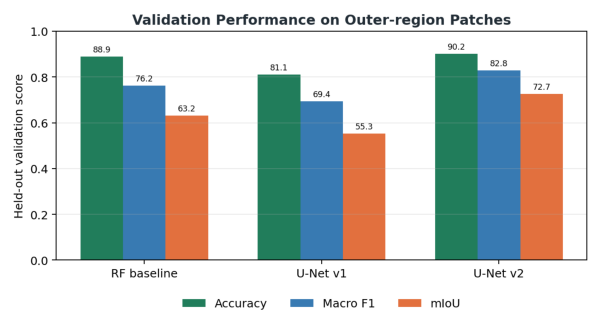

In [12]:
# Display the summary metric figure.
fig = mpimg.imread(FIG_DIR / "validation_overall_metrics_for_template.png")
plt.figure(figsize=(8, 4))
plt.imshow(fig)
plt.axis("off")
plt.show()

### Per-class performance

The strongest overall model is still not equally strong across all classes. Plantation remains the most difficult class and is frequently confused with forest, which is consistent with the spectral similarity of rubber, oil palm, and evergreen vegetation in Sentinel-2 imagery.

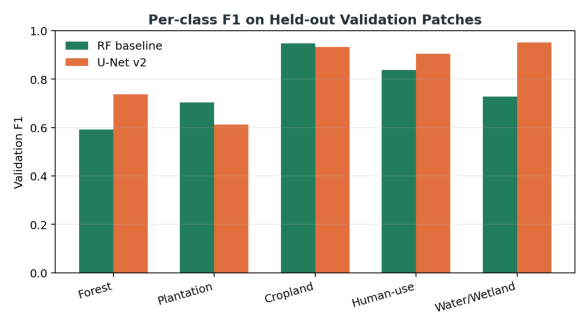

In [13]:
# Display per-class F1 figure.
fig = mpimg.imread(FIG_DIR / "validation_per_class_f1_for_template.png")
plt.figure(figsize=(8, 4))
plt.imshow(fig)
plt.axis("off")
plt.show()

### Confusion patterns

Confusion matrices help explain *why* the classes differ in performance. The matrices below are row-normalized: each row sums to 100% and shows where each true class is being predicted.

**Key takeaways**

- U-Net v2 has a stronger diagonal than U-Net v1, indicating better class separation.
- Cropland and Water/Wetland are relatively stable classes.
- Plantation remains the main failure mode and is often confused with Forest.

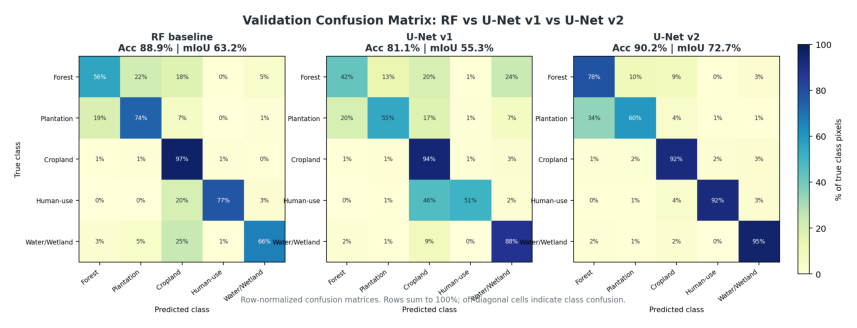

In [14]:
# Display confusion matrix comparison.
fig = mpimg.imread(FIG_DIR / "validation_confusion_matrix_three_models.png")
plt.figure(figsize=(12, 4))
plt.imshow(fig)
plt.axis("off")
plt.show()

### Qualitative patch diagnostics

Quantitative metrics are necessary but not sufficient. We also compare visual segmentation quality on selected validation patches.

**Patch A: large improvement from U-Net v1 to U-Net v2**

- RF baseline patch accuracy: 72.6%
- U-Net v1 patch accuracy: 29.3%
- U-Net v2 patch accuracy: 89.7%

**Patch B: non-urban example with nearly no Human-use pixels**

- RF baseline patch accuracy: 78.3%
- U-Net v1 patch accuracy: 62.7%
- U-Net v2 patch accuracy: 93.4%

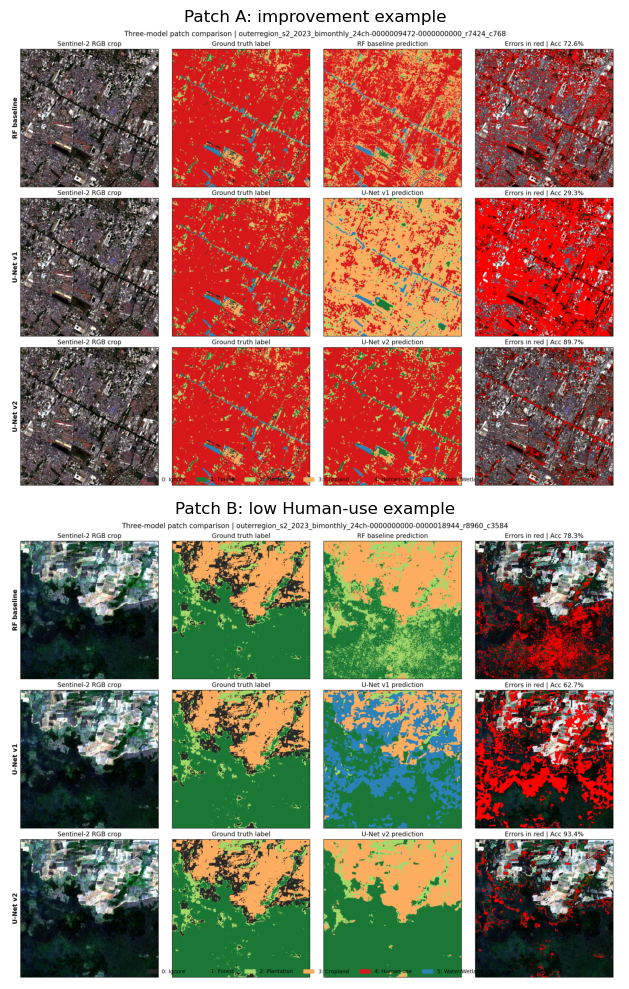

In [15]:
# Display qualitative patch examples.
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
axes[0].imshow(mpimg.imread(FIG_DIR / "best_patch_all_models.png"))
axes[0].axis("off")
axes[0].set_title("Patch A: improvement example")
axes[1].imshow(mpimg.imread(FIG_DIR / "no_city_patch_all_models.png"))
axes[1].axis("off")
axes[1].set_title("Patch B: low Human-use example")
plt.tight_layout()
plt.show()

### Study-region inference

We treat the study-region map as an **application output**, not as the primary source of accuracy reporting, because we do not have independent ground-truth labels for the final target region.

The inference script runs sliding-window prediction over each large raster tile and averages overlapping softmax probabilities before writing the final class map.

```python
# final_project_files/scripts/predict_raster.py
positions = iterate_positions(height, width, args.tile_size, args.stride)
prob_sum = np.zeros((args.num_classes, height, width), dtype=np.float32)
count_sum = np.zeros((height, width), dtype=np.float32)

with torch.no_grad():
    for row, col in positions:
        window = Window(col, row, min(args.tile_size, width - col), min(args.tile_size, height - row))
        chip = src.read(window=window).astype(np.float32)

        padded = np.zeros((args.in_channels, args.tile_size, args.tile_size), dtype=np.float32)
        padded[:, : chip.shape[1], : chip.shape[2]] = chip[: args.in_channels]
        padded = normalize_tile(padded, normalization=args.normalization, mean=norm_mean, std=norm_std)

        tensor = torch.from_numpy(padded[None, ...]).to(device)
        probs = torch.softmax(model(tensor), dim=1).cpu().numpy()[0]
        prob_sum[:, row : row + valid_h, col : col + valid_w] += probs[:, :valid_h, :valid_w]
        count_sum[row : row + valid_h, col : col + valid_w] += 1.0

pred = np.argmax(prob_sum / count_sum[None, :, :], axis=0).astype(np.uint8) + 1
```

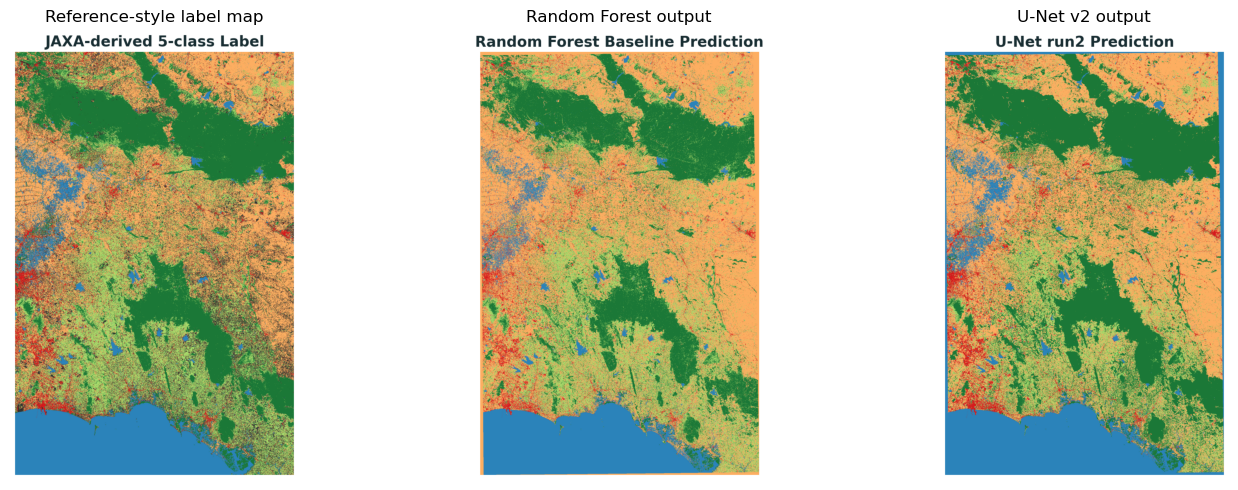

In [16]:
# Display the study-region application outputs.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, name, title in zip(
    axes,
    ["studyregion_label_map.png", "studyregion_rf_map.png", "studyregion_unet_map.png"],
    ["Reference-style label map", "Random Forest output", "U-Net v2 output"],
):
    ax.imshow(mpimg.imread(FIG_DIR / name))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Part1 Limitations

- **No independent ground-truth labels in the final study region.** Final model performance is mainly assessed on held-out validation patches, while the study-region map is treated as an application output.
- **Validation is patch-level rather than fully spatial hold-out.** Because overlapping patches were used, some spatial correlation may remain between training and validation samples.
- **The class schema is simplified to five classes.** Bare land and grassland were excluded and assigned to the ignore category, which reduces task complexity but also limits landscape realism.
- **Plantation remains difficult to separate from forest.** Rubber, oil palm, and forest can show similar spectral and seasonal patterns in Sentinel-2 imagery.
- **Training labels come from remapped reference data rather than field-verified annotations.** Any uncertainty in the original JAXA labels may propagate into model training and evaluation.
- **Model development was constrained by local computing resources.** Training depth, hyperparameter search, and augmentation experiments were limited by laptop-scale hardware.

## Part1 Future Work

With more time or resources, we would:

- collect or derive cleaner labels for plantation and forest classes;
- use spatial block validation instead of overlapping patch hold-out;
- add richer temporal features or a longer time window beyond six bi-monthly composites;
- test stronger segmentation backbones and more extensive augmentation;
- operationalize the workflow for repeated monitoring and downstream conservation decision support.

---

# Part 2: Habitat Suitability Modeling

The segmentation output from Part I is not an end product by itself — it becomes a structured ecological input for downstream habitat modeling.

The U-Net v2 land cover map is converted into landscape composition features by summarizing the proportional coverage of each of the five land-cover classes within a 1 km buffer around each sample point. These composition features, combined with mean NDVI, form the predictor set for a Random Forest habitat suitability model. The model is trained on 261 known elephant occurrence points and 3,000 randomly drawn background points, and is then applied across the full study region to produce a continuous elephant presence probability surface.

## Objective

The model estimates the probability of elephant presence for each location based on two types of environmental information:

1. **Land-cover composition** — derived from the five-class segmentation map produced in Part I
2. **Vegetation condition** — represented by NDVI

The final result is a spatial probability surface identifying areas of relatively high and low suitability for elephant presence.


In [23]:
# =========================================================
# 0. Import packages
# =========================================================

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import rasterio
from rasterio.enums import Resampling
from shapely.geometry import Point

from scipy.ndimage import uniform_filter

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

In [24]:
# =========================================================
# 1. File paths
# =========================================================

base_dir = os.getcwd()
data_dir = os.path.join(base_dir, r"final_project_files/data")

landcover_fp = os.path.join(
    data_dir,
    "unet_merged_4326.tif"
)

ndvi_fp = os.path.join(
    data_dir,
    "NDVI_4326.tif"
)

elephant_fp = os.path.join(
    data_dir,
    "elephant_efcom_points.geojson"
)

output_fp = os.path.join(
    data_dir,
    "elephant_habitat_suitability_final.tif"
)

In [25]:
# =========================================================
# 2. Parameters
# =========================================================

# downsample
downsample_factor = 5

# buffer radius
# since now CRS is projected and can use meters directly
buffer_radius_m = 1000

radius_pixels = 200
window_size = radius_pixels * 2 + 1

# IMPORTANT:
# modify according to your real classes
landcover_classes = [1, 2, 3, 4, 5]

print("Parameters set.")

Parameters set.


## Input Data

Three main datasets are used:

- **Classified land-cover raster**: the segmented output from Part I, saved as a merged raster in geographic coordinates
- **NDVI raster**: a vegetation index layer representing greenness and vegetation intensity
- **Elephant occurrence points**: observed elephant locations stored as point data

The land-cover raster provides the main structural description of the landscape, while NDVI adds ecological information on vegetation condition. Elephant occurrence points are treated as presence samples for supervised model training.

In [26]:
# =========================================================
# 3. Read raster + downsample
# =========================================================

with rasterio.open(landcover_fp) as src_lc:

    new_height = src_lc.height // downsample_factor
    new_width = src_lc.width // downsample_factor

    print("Original LC size:",
          src_lc.height, "x", src_lc.width)

    print("Downsampled LC size:",
          new_height, "x", new_width)

    # landcover must use MODE
    lc_array = src_lc.read(
        1,
        out_shape=(new_height, new_width),
        resampling=Resampling.mode
    )

    new_transform = src_lc.transform * src_lc.transform.scale(
        src_lc.width / new_width,
        src_lc.height / new_height
    )

    raster_crs = src_lc.crs
    nodata_value = src_lc.nodata


with rasterio.open(ndvi_fp) as src_ndvi:

    # NDVI should use AVERAGE
    ndvi_array = src_ndvi.read(
        1,
        out_shape=(new_height, new_width),
        resampling=Resampling.average
    )

Original LC size: 26795 x 18218
Downsampled LC size: 5359 x 3643


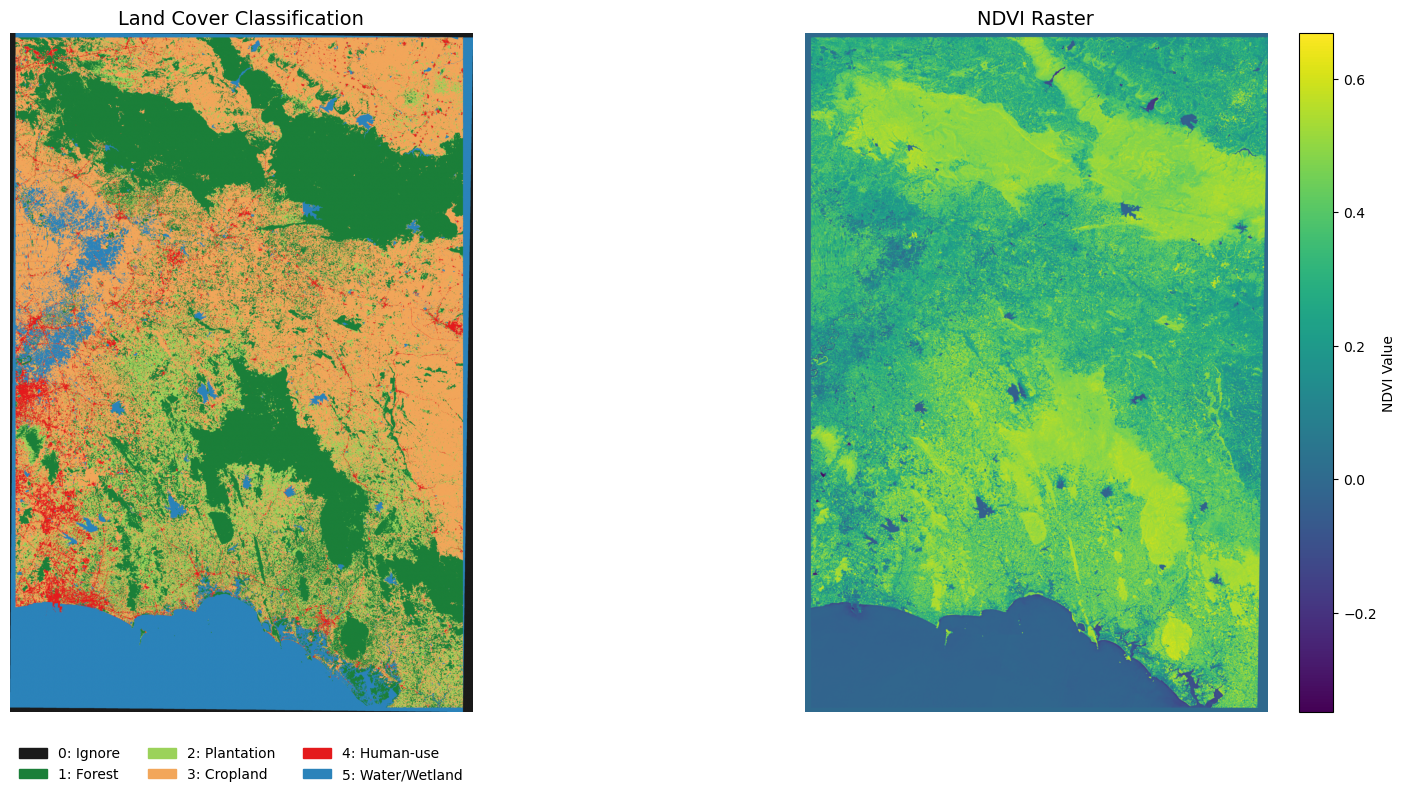

In [27]:
# =========================================================
# Plot Land Cover + NDVI
# =========================================================

# -----------------------------
# Land Cover style settings
# -----------------------------
class_colors = [
    "#1a1a1a",  # 0 Ignore (black)
    "#1b7f39",  # 1 Forest (dark green)
    "#9bd25a",  # 2 Plantation (light green)
    "#f2a65a",  # 3 Cropland (orange)
    "#e41a1c",  # 4 Human-use (red)
    "#2b83ba"   # 5 Water/Wetland (blue)
]

class_labels = [
    "0: Ignore",
    "1: Forest",
    "2: Plantation",
    "3: Cropland",
    "4: Human-use",
    "5: Water/Wetland"
]

custom_cmap = ListedColormap(class_colors)

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 8)
)

# =========================================================
# Left: Land Cover Classification
# =========================================================

im1 = axes[0].imshow(
    lc_array,
    cmap=custom_cmap,
    vmin=0,
    vmax=5
)

axes[0].set_title("Land Cover Classification", fontsize=14)
axes[0].axis("off")

# custom legend
legend_patches = [
    mpatches.Patch(
        color=class_colors[i],
        label=class_labels[i]
    )
    for i in range(len(class_labels))
]

axes[0].legend(
    handles=legend_patches,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=False,
    fontsize=10
)

# =========================================================
# Right: NDVI Raster
# =========================================================

im2 = axes[1].imshow(
    ndvi_array,
    cmap="viridis"
)

axes[1].set_title("NDVI Raster", fontsize=14)
axes[1].axis("off")

# colorbar for NDVI
cbar = fig.colorbar(
    im2,
    ax=axes[1],
    fraction=0.046,
    pad=0.04
)
cbar.set_label("NDVI Value")

plt.tight_layout()
plt.show()

## Presence and Background Samples

The elephant point dataset represents known presence locations. These points are labeled as **presence = 1**.

To create a contrast for supervised classification, 3,000 random background points are generated across the study area and labeled as **presence = 0**. These background points do not necessarily indicate confirmed absence, but they provide a representative sample of the broader landscape against which observed elephant locations can be compared.

This presence-background design allows the model to learn which environmental conditions are more strongly associated with elephant occurrence than with the surrounding landscape in general.

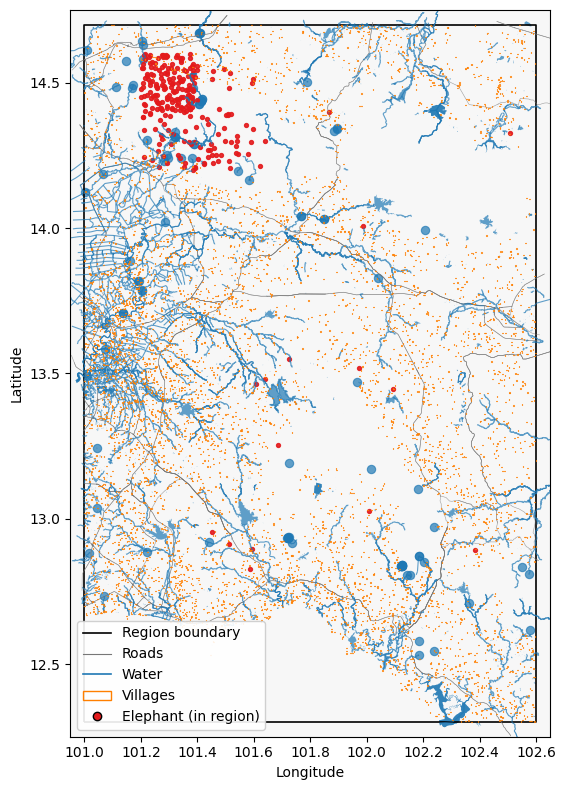

In [28]:
# Elephant occurence points and relevant physical features overview

study_region_path = Path(data_dir) / "studyregion.geojson"
region = gpd.read_file(study_region_path)

roads = gpd.read_file(Path(data_dir) / "major_roads.geojson")
villages = gpd.read_file(Path(data_dir) / "village_polygon.geojson")
water = gpd.read_file(Path(data_dir) / "water_efcom.geojson")
occ = gpd.read_file(Path(data_dir) / "occurrence.geojson")

region_union = region.unary_union
occ_in_region = occ[occ.within(region_union)].copy()

minx, miny, maxx, maxy = region.total_bounds

fig, ax = plt.subplots(figsize=(6, 8))

# 1. Region Boundary
region.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=1.2
)

# 2. Roads
roads.plot(
    ax=ax,
    linewidth=0.4,
    color="#777777",
    alpha=0.7
)

# 3. Water
water.plot(
    ax=ax,
    linewidth=0.8,
    color="#1f78b4",
    alpha=0.7
)

# 4. Villages Boundary
villages.boundary.plot(
    ax=ax,
    linewidth=0.8,
    edgecolor="#ff7f00",
    alpha=0.8
)

# 5. Occurances
occ_in_region.plot(
    ax=ax,
    markersize=8,
    color="#e31a1c",
    alpha=0.9
)

ax.set_xlim(minx - 0.05, maxx + 0.05)
ax.set_ylim(miny - 0.05, maxy + 0.05)


ax.set_facecolor("#f7f7f7")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

legend_elements = [
    Line2D([0], [0], color="black", lw=1.2, label="Region boundary"),
    Line2D([0], [0], color="#777777", lw=0.8, label="Roads"),
    Line2D([0], [0], color="#1f78b4", lw=1.2, label="Water"),
    Patch(facecolor="none", edgecolor="#ff7f00", label="Villages"),
    Line2D([0], [0], marker="o", color="none",
           markerfacecolor="#e31a1c", markersize=6,
           label="Elephant (in region)")
]

ax.legend(handles=legend_elements, loc="lower left", frameon=True, framealpha=0.9)

plt.tight_layout()
plt.show()

In [29]:
# =========================================================
# 4. Read elephant points
# =========================================================

gdf_ele = gpd.read_file(elephant_fp)

print("Elephant points:", len(gdf_ele))

if gdf_ele.crs != raster_crs:
    gdf_ele = gdf_ele.to_crs(raster_crs)

gdf_ele["presence"] = 1
gdf_ele = gdf_ele[["presence", "geometry"]]


# =========================================================
# 5. Generate 3000 random background points
# =========================================================

with rasterio.open(landcover_fp) as src:
    bounds = src.bounds

minx, miny, maxx, maxy = bounds

np.random.seed(42)

random_points = []

print("Generating random background points...")

while len(random_points) < 3000:
    x = np.random.uniform(minx, maxx)
    y = np.random.uniform(miny, maxy)

    try:
        row, col = rasterio.transform.rowcol(
            new_transform,
            x,
            y
        )

        if (
            0 <= row < lc_array.shape[0]
            and 0 <= col < lc_array.shape[1]
        ):
            value = lc_array[row, col]

            if (
                value != nodata_value
                and not np.isnan(value)
            ):
                random_points.append(
                    Point(x, y)
                )

    except:
        continue

gdf_bg = gpd.GeoDataFrame(
    {
        "presence": [0] * len(random_points)
    },
    geometry=random_points,
    crs=raster_crs
)

print("Background points:", len(gdf_bg))


# =========================================================
# 6. Combine presence + background
# =========================================================

gdf_all = pd.concat(
    [gdf_ele, gdf_bg],
    ignore_index=True
)

print("Total samples:", len(gdf_all))

Elephant points: 261
Generating random background points...
Background points: 3000
Total samples: 3261


## Feature Engineering

Elephant habitat use is influenced by surrounding landscape context rather than by a single pixel alone.

Therefore, a neighborhood-based feature extraction approach is used. For each point, a 1km buffer window is defined around the corresponding raster cell, and environmental features are calculated from that surrounding area.

Within each neighborhood window, the model derives:

- the proportion of each of the five land-cover classes
- the mean NDVI value

As a result, each sample is described not just by one class label, but by a small set of contextual variables representing landscape composition and vegetation condition.

In [31]:
# =========================================================
# 7. Extract predictors
#
# For each point:
#   - landcover proportion
#   - NDVI mean value
# =========================================================

def extract_features(
    point,
    lc_raster,
    ndvi_raster,
    transform,
    radius=5,
    classes=[1, 2, 3, 4, 5]
):
    try:
        x, y = point.x, point.y

        row, col = rasterio.transform.rowcol(
            transform,
            x,
            y
        )

        row_min = max(0, row - radius)
        row_max = min(
            lc_raster.shape[0],
            row + radius
        )

        col_min = max(0, col - radius)
        col_max = min(
            lc_raster.shape[1],
            col + radius
        )

        lc_window = lc_raster[
            row_min:row_max,
            col_min:col_max
        ]

        ndvi_window = ndvi_raster[
            row_min:row_max,
            col_min:col_max
        ]

        valid_pixels = lc_window[
            lc_window != nodata_value
        ]

        if len(valid_pixels) == 0:
            return [np.nan] * (len(classes) + 1)

        proportions = []

        for cls in classes:
            pct = np.sum(
                valid_pixels == cls
            ) / len(valid_pixels)

            proportions.append(pct)

        # NDVI mean
        ndvi_mean = np.nanmean(
            ndvi_window
        )

        return proportions + [ndvi_mean]

    except:
        return [np.nan] * (len(classes) + 1)


print("Extracting features...")

feature_names = [
    f"class_{cls}_pct"
    for cls in landcover_classes
] + ["ndvi_mean"]

feature_values = gdf_all.geometry.apply(
    lambda geom: extract_features(
        geom,
        lc_array,
        ndvi_array,
        new_transform,
        radius=radius_pixels,
        classes=landcover_classes
    )
)

feature_df = pd.DataFrame(
    feature_values.tolist(),
    columns=feature_names
)

df = pd.concat(
    [
        gdf_all.reset_index(drop=True),
        feature_df
    ],
    axis=1
)

df = df.dropna()

print(df.head())

Extracting features...
   presence                    geometry  class_1_pct  class_2_pct  \
0         1  POINT (101.20073 14.44923)     0.903925     0.034319   
1         1  POINT (101.45096 14.51415)     0.507062     0.140350   
2         1  POINT (101.34412 14.58563)     0.361075     0.238981   
3         1  POINT (101.25046 14.45802)     0.972931     0.013531   
4         1   POINT (101.2909 14.59323)     0.450656     0.182481   

   class_3_pct  class_4_pct  class_5_pct  ndvi_mean  
0     0.057313     0.003737     0.000706   0.474858  
1     0.321387     0.025544     0.005656   0.412713  
2     0.338487     0.056781     0.004675   0.372614  
3     0.012162     0.000819     0.000556   0.496796  
4     0.317156     0.046244     0.003462   0.376310  


## Model Training

After feature extraction, the sample dataset is split into training and testing subsets using a stratified train-test split.

The Random Forest classifier is then trained on the extracted predictors. The trained model is first evaluated on the held-out test set and is then applied to the full raster extent to generate a continuous habitat suitability surface.

In [32]:
# =========================================================
# 8. Train Random Forest
# =========================================================

X = df[feature_names]
y = df["presence"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

y_prob = rf.predict_proba(
    X_test
)[:, 1]

auc = roc_auc_score(
    y_test,
    y_prob
)

print("\nRandom Forest AUC:",
      round(auc, 3))


Random Forest AUC: 0.947


## Full-Map Prediction

For each raster location, the same neighborhood-based predictors used during training are calculated. Predictors are passed into the trained model, which returns the predicted probability of elephant presence. Repeating this process across the full study area creates a continuous spatial surface of habitat suitability.

In [33]:
# =========================================================
# 9. Fast full-map prediction
#
# Use:
#   uniform_filter for LC proportions
#   + NDVI layer
# =========================================================

print("\nGenerating habitat suitability map...")

feature_stack = []

for cls in landcover_classes:
    print(f"Processing class {cls}...")

    binary = (
        lc_array == cls
    ).astype(np.float32)

    proportion = uniform_filter(
        binary,
        size=window_size,
        mode="nearest"
    )

    feature_stack.append(
        proportion
    )

# add NDVI directly
feature_stack.append(
    ndvi_array.astype(np.float32)
)

feature_stack = np.stack(
    feature_stack,
    axis=-1
)

rows, cols, n_features = feature_stack.shape

print("Feature stack shape:",
      feature_stack.shape)

X_pred = feature_stack.reshape(
    rows * cols,
    n_features
).astype(np.float32)

print("Predicting probabilities...")

pred_prob = rf.predict_proba(
    X_pred
)[:, 1]

prob_map = pred_prob.reshape(
    rows,
    cols
)

if nodata_value is not None:
    prob_map[
        lc_array == nodata_value
    ] = np.nan

print("Prediction finished.")


Generating habitat suitability map...
Processing class 1...
Processing class 2...
Processing class 3...
Processing class 4...
Processing class 5...
Feature stack shape: (5359, 3643, 6)
Predicting probabilities...
Prediction finished.


## Results: Habitat Suitability Map

The final habitat suitability map shows the spatial distribution of predicted elephant presence probability across the study area. That is a continuous probability surface, which allows more nuanced interpretation of habitat conditions.

In [10]:
# =========================================================
# 10. Save GeoTIFF
# =========================================================

with rasterio.open(
    output_fp,
    "w",
    driver="GTiff",
    height=rows,
    width=cols,
    count=1,
    dtype="float32",
    crs=raster_crs,
    transform=new_transform,
    nodata=np.nan
) as dst:

    dst.write(
        prob_map.astype(np.float32),
        1
    )

print("\nSaved final map:")
print(output_fp)


Saved final map:
C:\Users\m1870\MUSA\deeplearning\final\data\elephant_habitat_suitability_final.tif


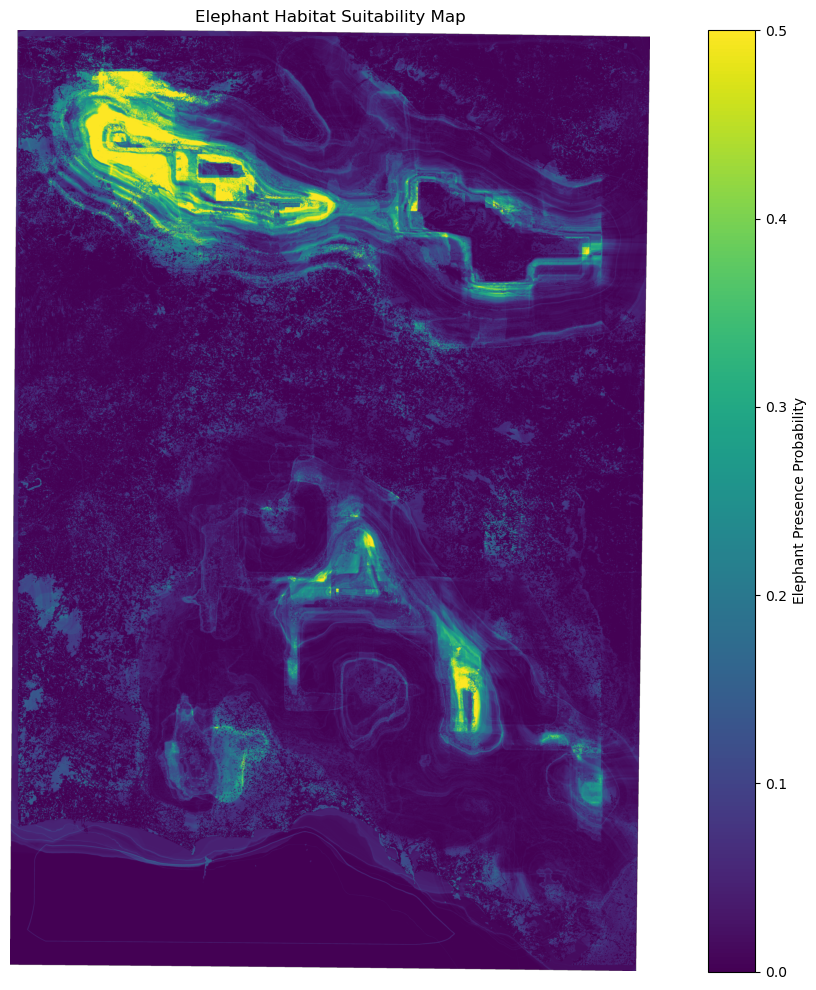

In [14]:
# =========================================================
# 11. Visualization
# =========================================================

plt.figure(
    figsize=(12, 10)
)

plt.imshow(
    prob_map,
    cmap="viridis",
    vmin=0,
    vmax=0.5
)

plt.colorbar(
    label="Elephant Presence Probability"
)

plt.title(
    "Elephant Habitat Suitability Map"
)

plt.axis("off")
plt.tight_layout()
plt.show()

## Evaluation Results

The model achieved an **AUC of 0.947**, indicating strong predictive performance on the test set.

The feature importance plot further helps explain which environmental variables drive the prediction most strongly. Together, these evaluation results suggest that the combination of segmentation-derived land-cover composition and NDVI provides a useful basis for modeling elephant habitat suitability.

AUC = 0.947


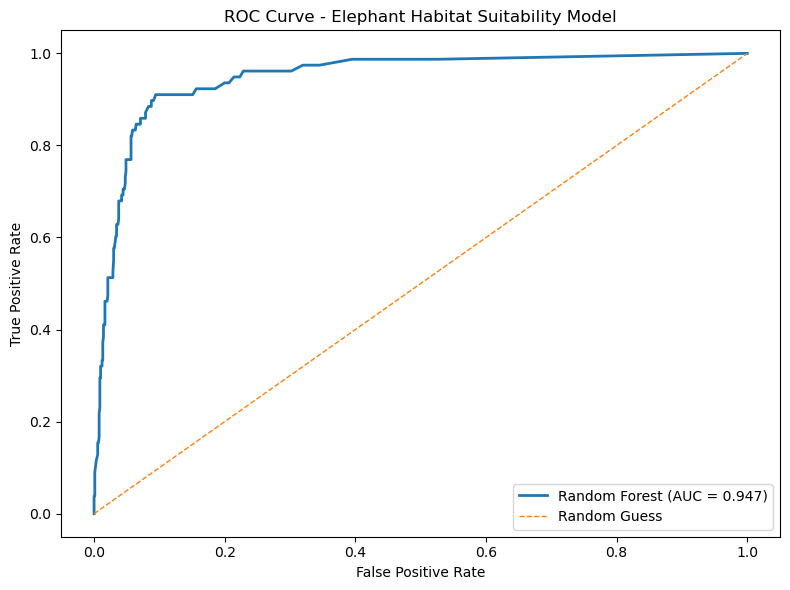


Feature Importance:
       Feature  Importance
4  class_5_pct    0.202590
3  class_4_pct    0.196366
0  class_1_pct    0.195259
5    ndvi_mean    0.145754
2  class_3_pct    0.136347
1  class_2_pct    0.123684


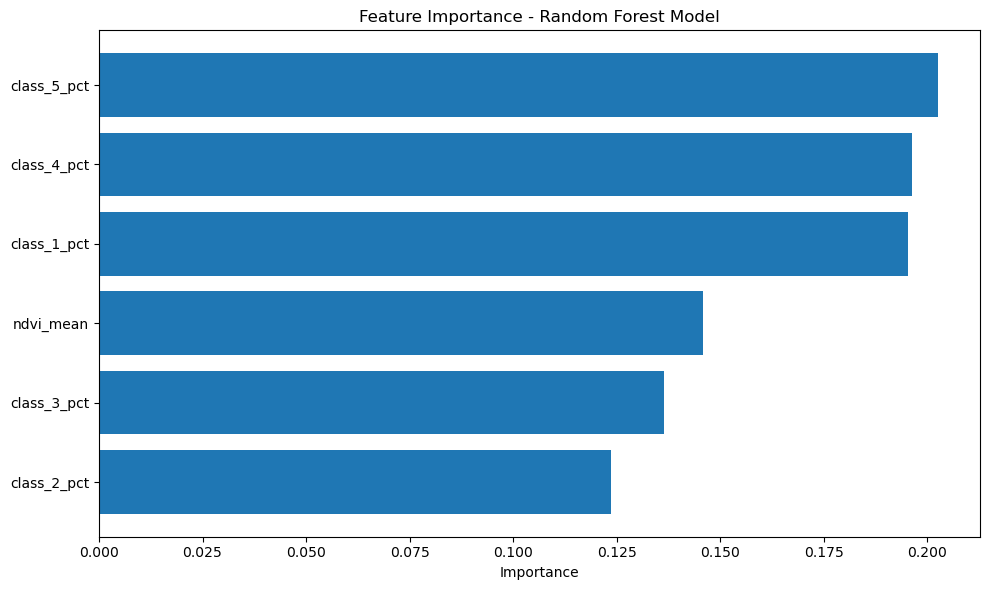

In [34]:
# =========================================================
# 12. Model Evaluation
# ROC Curve
# Feature Importance
# =========================================================

from sklearn.metrics import roc_curve, roc_auc_score

# =========================================================
# 1. ROC Curve
# =========================================================

# probability from test set
y_prob = rf.predict_proba(X_test)[:, 1]

# calculate ROC
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc_value = roc_auc_score(
    y_test,
    y_prob
)

print("AUC =", round(auc_value, 3))


plt.figure(figsize=(8, 6))

# ROC line
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Random Forest (AUC = {auc_value:.3f})"
)

# reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Elephant Habitat Suitability Model")
plt.legend()
plt.tight_layout()
plt.show()


# =========================================================
# 2. Feature Importance
# =========================================================

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(importance_df)


plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.title("Feature Importance - Random Forest Model")

# highest importance on top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Part 2 Limitations

Several limitations should be considered for part2.

First, the accuracy of the final habitat suitability map **depends heavily on the quality of the land-cover segmentation in Part I**. Segmentation errors may still occur, especially in areas where land-cover boundaries are unclear or where classes have similar spectral characteristics.

Second, the current habitat suitability model uses a **limited set of predictors**, mainly the five land-cover classes and NDVI. Elephant movement and habitat selection are also influenced by other factors such as distance to water, roads, villages, terrain, seasonal changes, and human disturbance.

Third, the background points used in the Random Forest suitability model **represent pseudo-absence rather than confirmed absence**. This means the model distinguishes known elephant locations from available landscape conditions rather than from true absence locations, which may introduce uncertainty in ecological interpretation.

## Overall Conclusion

This project developed a two-stage framework for elephant habitat suitability analysis by combining deep learning land-cover segmentation with occurrence-based machine learning.

In Part I, a Random Forest pixel baseline and two U-Net variants were trained on multi-temporal Sentinel-2 imagery. U-Net v2, which introduced global normalization and a combined weighted cross-entropy and Dice loss, achieved **90.2% overall accuracy** and **72.7% mIoU** on the held-out validation set — improving over the Random Forest baseline (88.9% accuracy, 63.2% mIoU) and the initial U-Net v1 (81.1% accuracy, 55.3% mIoU). The resulting five-class land cover map provides a spatially consistent and ecologically meaningful description of the EFCOM landscape.

In Part II, land-cover composition proportions within 1 km buffers, together with NDVI, were used as predictors in a Random Forest habitat suitability model. The model achieved an **AUC of 0.947** on the held-out test set, indicating strong discriminative ability. The final habitat suitability map reveals that high-probability zones are concentrated along forest-edge and mixed-use transition areas in the northern part of the study region, consistent with known elephant movement patterns in the EFCOM landscape.

Together, these results demonstrate that deep learning segmentation can serve as more than a visual mapping tool: by converting raw imagery into structured ecological predictors, it directly supports species distribution modeling and conservation planning.


## Reproducibility and File Organization

To keep this notebook readable and GitHub-friendly, heavy training and full-region prediction steps are included as **code references or curated code snippets**, not rerun here. The supporting files are organized in `final_project_files/`:

- `figures/`: static PNGs for notebook rendering and presentation reuse
- `tables/`: validation metrics, training curves, and patch summary files
- `scripts/`: export, preprocessing, training, evaluation, and prediction scripts
- `configs/`: class remapping configuration

**Key scripts**

- `final_project_files/scripts/earth_engine_export_s2_bimonthly_stack.js`
- `final_project_files/scripts/reclass_and_clip_jaxa.py`
- `final_project_files/scripts/align_labels_to_imagery.py`
- `final_project_files/scripts/tile_training_data.py`
- `final_project_files/scripts/train_random_forest_baseline.py`
- `final_project_files/scripts/train_unet.py`
- `final_project_files/scripts/evaluate_unet.py`
- `final_project_files/scripts/predict_raster.py`

## References

**Data Sources**

- Sentinel-2 Surface Reflectance via Google Earth Engine (COPERNICUS/S2_SR_HARMONIZED)
- JAXA 10 m Southeast Asia Land Cover Product (2023)
- Elephant occurrence data: GBIF — 261 georeferenced presence points within EFCOM

**Course Materials**

- MUSA 650 Final Project assignment brief: [FINAL_PROJECT.md](https://github.com/MUSA-650/musa-650-spring2026/blob/main/assignments/FINAL_PROJECT.md)

**Methodological Sources**

1. He et al. (2023). Evaluation of Habitat Suitability for Asian Elephants in Sipsongpanna under Climate Change by Coupling Multi-Source Remote Sensing Products with MaxEnt Model.
2. Nomura et al. (2018). More Than Meets the Eye: Using Sentinel-2 to Map Small-Scale Plantations in Complex Forest Landscapes.
3. van der Plas et al. (2023). Multi-Stage Semantic Segmentation Quantifies Fragmentation of Small Habitats at a Landscape Scale.
4. Suksavate et al. (2023). Quantifying Landscape Connectivity and Potential Corridors for Wild Asian Elephants in Eastern Thailand. *Diversity*, 15, 6.
